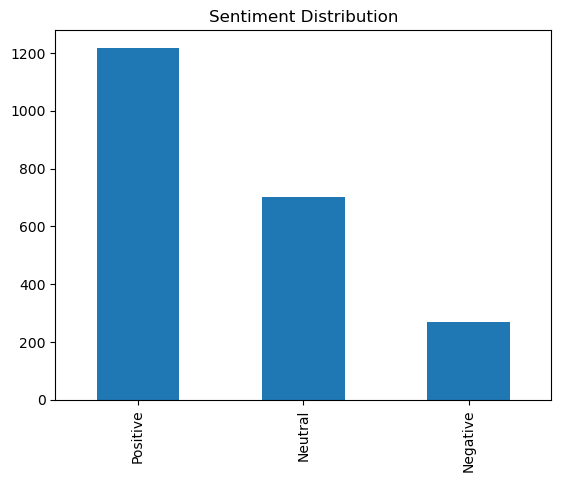

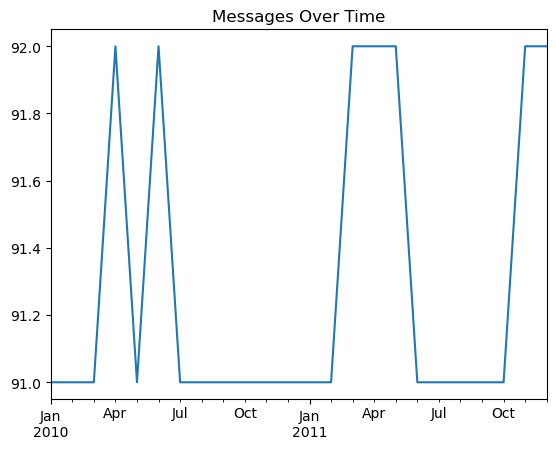

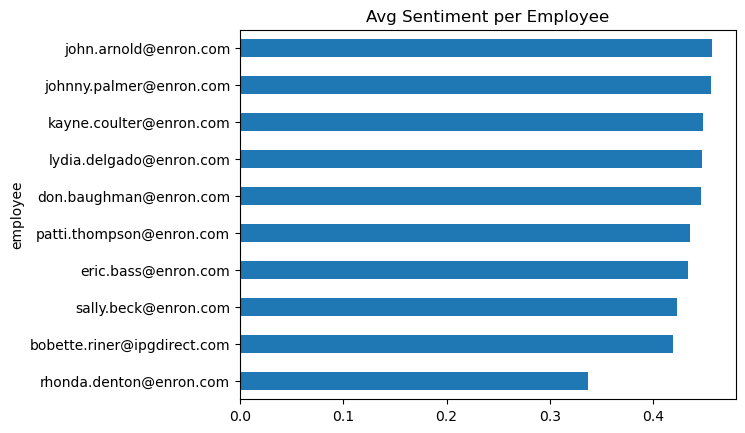

Top Employees (Positive):
employee
lydia.delgado@enron.com     127
john.arnold@enron.com       117
patti.thompson@enron.com     98
johnny.palmer@enron.com      97
sally.beck@enron.com         96
Name: score, dtype: int64

Low Sentiment Employees:
employee
don.baughman@enron.com         95
bobette.riner@ipgdirect.com    91
eric.bass@enron.com            91
kayne.coulter@enron.com        78
rhonda.denton@enron.com        58
Name: score, dtype: int64

Flight Risk Employees:
employee                     date      
bobette.riner@ipgdirect.com  2010-11-17    4.0
                             2010-11-19    5.0
                             2011-04-01    4.0
                             2011-04-17    5.0
don.baughman@enron.com       2010-03-07    4.0
                             2010-05-26    4.0
eric.bass@enron.com          2010-04-15    4.0
                             2010-09-30    4.0
                             2010-10-04    5.0
                             2011-06-01    4.0
              

In [32]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.linear_model import LinearRegression

# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("test.csv")

# Rename columns for consistency
df = df.rename(columns={'from': 'employee'})

# Convert date column
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Create month column
df['month'] = df['date'].dt.to_period('M')

# ================================
# 3. Sentiment Analysis
# ================================
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment on email body
df['Sentiment'] = df['body'].apply(get_sentiment)

# Convert sentiment to score
score_map = {'Positive': 1, 'Negative': -1, 'Neutral': 0}
df['score'] = df['Sentiment'].map(score_map)

# ================================
# 4. EDA & Visualization
# ================================

# Sentiment Distribution
df['Sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')
plt.show()

# Messages over time
df['month'].value_counts().sort_index().plot(kind='line', title='Messages Over Time')
plt.show()

# Average sentiment per employee
df.groupby('employee')['score'].mean().sort_values().plot(kind='barh', title='Avg Sentiment per Employee')
plt.show()

# ================================
# 5. Monthly Sentiment Scoring
# ================================
monthly_scores = df.groupby(['employee', 'month'])['score'].sum().reset_index()

# ================================
# 6. Employee Ranking
# ================================
employee_rank = df.groupby('employee')['score'].sum().sort_values(ascending=False)
print("Top Employees (Positive):")
print(employee_rank.head())

print("\nLow Sentiment Employees:")
print(employee_rank.tail())

# ================================
# 7. Flight Risk Identification
# ================================

# Filter negative messages
neg_msgs = df[df['Sentiment'] == 'Negative']

# Sort properly (VERY IMPORTANT)
neg_msgs = neg_msgs.sort_values(by=['employee', 'date'])

# Rolling 30-day negative count
flight_risk = neg_msgs.groupby('employee')\
    .rolling('30D', on='date')['score'].count()

# Employees with >= 4 negative messages in 30 days
flight_risk = flight_risk[flight_risk >= 4]

print("\nFlight Risk Employees:")
print(flight_risk)

# ================================
# 8. Linear Regression Model
# ================================

# Feature engineering
features = df.groupby('employee').agg({
    'body': 'count'
}).rename(columns={'body': 'msg_count'})

# Add total sentiment score
features['score'] = df.groupby('employee')['score'].sum()

# Define X and y
X = features[['msg_count']]
y = features['score']

# Train model
model = LinearRegression()
model.fit(X, y)

# Print model results
print("\nModel Coefficient:", model.coef_)
print("Model Intercept:", model.intercept_)

# Predictions
y_pred = model.predict(X)
print("\nSample Predictions:", y_pred[:5])